# PART 1: PREPROCESSING DATA

# 1. LOAD DATA
1. including  necessary libraries and loading csv file into an data frame.
2. displaying datasets row and column count by checking its shape. 
3. displaying first 5 records.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
import joblib
warnings.filterwarnings('ignore')

In [2]:
file_path = './ai-impact-jobs-layoff-risk-dataset.csv'
df = pd.read_csv(file_path)

print("=" * 60)
print("Loading data")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")

Loading data
Shape: (20000, 16)
Columns: ['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'AI_Adoption_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours', 'Layoff_Risk']

First 5 rows:
   Age Education_Level  Years_of_Experience       Industry  \
0   59        Master's                    6        Finance   
1   44        Master's                   14  Manufacturing   
2   36      Bachelor's                    7         Retail   
3   27      Bachelor's                    6        Finance   
4   49     High School                   12        Finance   

                Job_Role Company_Size Job_Level  Routine_Task_Percentage  \
0             Accountant       Medium     Entry                       84   
1  Production Supervisor        Small     Entry                       30   
2          Store Ma

# 2. CHECK NULL VALUES

In [3]:
print("\n" + "=" * 60)
print("Checking null values")
print("=" * 60)
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if any(null_counts > 0) else "No null values found!")
print(f"Total null values: {df.isnull().sum().sum()}")



Checking null values
No null values found!
Total null values: 0


# 3. CHECK DUPLICATES

In [4]:
print("\n" + "=" * 60)
print("Checking duplicate records")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Total duplicate records found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Shape after removing duplicates: {df.shape}")


Checking duplicate records
Total duplicate records found: 0


# 4. CHECK DATA CONSISTENCY
checking if there is any invalid data including age, years of experience and percentage validation.

In [5]:
print("\n" + "=" * 60)
print("Checking data consistency")
print("=" * 60)

# Age validation
invalid_age = df[(df['Age'] < 18) | (df['Age'] > 100)]
print(f"Invalid age (>100 or <18) {len(invalid_age)}")

# Years of experience validation (cannot be > age)
invalid_exp = df[df['Years_of_Experience'] > df['Age'] - 15]
print(f"Invalide experience (More than resoanble age) {len(invalid_exp)}")

# Percentages validation (should be 0-100)
percentage_cols = ['Routine_Task_Percentage', 'Creativity_Requirement', 
                    'Human_Interaction_Level', 'Tasks_Automated_Percentage']
for col in percentage_cols:
    invalid_pct = df[(df[col] < 0) | (df[col] > 100)]
    if len(invalid_pct) > 0:
        print(f"{col}: {len(invalid_pct)} invalid vlaue")


Checking data consistency
Invalid age (>100 or <18) 0
Invalide experience (More than resoanble age) 0


# 5. CHECK OUTLIERS (using IQR method)
checking outliers by IQR methode:
finding the data betweeen 1st and 3rd quarter and comparing with data that are out of this range.

In [6]:
print("\n" + "=" * 60)
print("Detecting outliers")
print("=" * 60)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)
    
    if len(outliers) > 0:
        print(f"\n{col}: {len(outliers)} outlier")
        print(f"Normal range: {lower_bound:.2f} - {upper_bound:.2f}")
        print(f"Top 5 outliers: {outliers[col].head(5).tolist()}")

# OPTION: Cap outliers (Winsorization) - UNCOMMENT IF NEEDED
# for col in numeric_cols:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     df[col] = df[col].clip(lower_bound, upper_bound)



Detecting outliers

Years_of_Experience: 46 outlier
Normal range: -6.50 - 21.50
Top 5 outliers: [23, 24, 23, 22, 22]

Number_of_AI_Tools_Used: 466 outlier
Normal range: -3.50 - 8.50
Top 5 outliers: [9, 9, 10, 10, 9]

AI_Usage_Hours_Per_Week: 721 outlier
Normal range: -10.00 - 22.00
Top 5 outliers: [27, 26, 23, 26, 30]

AI_Training_Hours: 949 outlier
Normal range: -17.00 - 39.00
Top 5 outliers: [70, 55, 68, 46, 68]


All these outlier Doesnt relly count as an outlier because they are all correct and pissble features so we dont need to erase any of them.

# 6. TARGET VARIABLE DISTRIBUTION

In [7]:
print("\n" + "=" * 60)
print("Checking tartget varable distribution")
print("=" * 60)
risk_dist = df['Layoff_Risk'].value_counts()
print(risk_dist)
print(f"\nPercentages: \n{df['Layoff_Risk'].value_counts(normalize=True) * 100}")


Checking tartget varable distribution
Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64

Percentages: 
Layoff_Risk
High      33.985
Low       33.010
Medium    33.005
Name: proportion, dtype: float64


# 7. ENCODING CATEGORICAL VARIABLES

In [8]:
print("\n" + "=" * 60)
print("Encoding Categorical Variables")
print("=" * 60)

# Show unique values before encoding
print("Unique values before encoding:")
print(f"Education_Level: {df['Education_Level'].unique()}")
print(f"Company_Size: {df['Company_Size'].unique()}")
print(f"Job_Level: {df['Job_Level'].unique()}")
print(f"AI_Adoption_Level: {df['AI_Adoption_Level'].unique()}")
print(f"Layoff_Risk: {df['Layoff_Risk'].unique()}")

# Encoding with pd.Categorical
df['Education_Level'] = pd.Categorical(
    df['Education_Level'], 
    categories=['High School', "Bachelor's", "Master's", 'PhD'], 
    ordered=True
).codes

df['Company_Size'] = pd.Categorical(
    df['Company_Size'], 
    categories=['Small', 'Medium', 'Large'], 
    ordered=True
).codes

df['Job_Level'] = pd.Categorical(
    df['Job_Level'], 
    categories=['Entry', 'Mid', 'Senior'], 
    ordered=True
).codes

df['AI_Adoption_Level'] = pd.Categorical(
    df['AI_Adoption_Level'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
).codes

df['Layoff_Risk'] = pd.Categorical(
    df['Layoff_Risk'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
).codes

# Check results
print("\nAfter encoding (first 5 records):")
print(f"Education_Level: {df['Education_Level'].head().tolist()}")
print(f"Company_Size: {df['Company_Size'].head().tolist()}")
print(f"Job_Level: {df['Job_Level'].head().tolist()}")
print(f"AI_Adoption_Level: {df['AI_Adoption_Level'].head().tolist()}")
print(f"Layoff_Risk: {df['Layoff_Risk'].head().tolist()}")

# One-Hot Encoding
print("\n🔄 Performing One-Hot Encoding for Industry and Job_Role...")
before_shape = df.shape
df = pd.get_dummies(df, columns=['Industry', 'Job_Role'], drop_first=False)
after_shape = df.shape
print(f"✅ Columns before: {before_shape[1]} -> after: {after_shape[1]}")

# Show first 5 new One-Hot Encoding columns
onehot_cols = [col for col in df.columns if col.startswith('Industry_') or col.startswith('Job_Role_')]
print(f"\nTotal new One-Hot columns: {len(onehot_cols)}")

# Show Industry columns
industry_cols = [col for col in onehot_cols if col.startswith('Industry_')]
print(f"\n📋 First 5 Industry columns: {industry_cols[:5]}")

# Show Job_Role columns
jobrole_cols = [col for col in onehot_cols if col.startswith('Job_Role_')]
print(f"📋 First 5 Job_Role columns: {jobrole_cols[:5]}")

# Show first 5 records from new columns
print("\n📊 First 5 records from Industry columns (sample):")
print(df[industry_cols[:5]].head())

print("\n📊 First 5 records from Job_Role columns (sample):")
print(df[jobrole_cols[:5]].head())



Encoding Categorical Variables
Unique values before encoding:
Education_Level: <StringArray>
['Master's', 'Bachelor's', 'High School', 'PhD']
Length: 4, dtype: str
Company_Size: <StringArray>
['Medium', 'Small', 'Large']
Length: 3, dtype: str
Job_Level: <StringArray>
['Entry', 'Senior', 'Mid']
Length: 3, dtype: str
AI_Adoption_Level: <StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str
Layoff_Risk: <StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str

After encoding (first 5 records):
Education_Level: [2, 2, 1, 1, 0]
Company_Size: [1, 0, 1, 2, 0]
Job_Level: [0, 0, 2, 0, 0]
AI_Adoption_Level: [1, 0, 0, 1, 1]
Layoff_Risk: [2, 0, 0, 2, 1]

🔄 Performing One-Hot Encoding for Industry and Job_Role...
✅ Columns before: 16 -> after: 46

Total new One-Hot columns: 32

📋 First 5 Industry columns: ['Industry_Education', 'Industry_Finance', 'Industry_Healthcare', 'Industry_IT', 'Industry_Logistics']
📋 First 5 Job_Role columns: ['Job_Role_Academic Coordinator', 'Job_Role_Accounta

# 8. FEATURE SCALING (Min-Max Normalization)

In [9]:
print("\n" + "=" * 60)
print("Normalizing features (Min-Max Scaling)")
print("=" * 60)

# Separate features and target
X = df.drop('Layoff_Risk', axis=1)
y = df['Layoff_Risk']

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"X_scaled shape: {X_scaled.shape}")
print(f"Min value: {X_scaled.min().min():.4f}")
print(f"Max value: {X_scaled.max().max():.4f}")
print("Scaling completed")



Normalizing features (Min-Max Scaling)
X_scaled shape: (20000, 45)
Min value: 0.0000
Max value: 1.0000
Scaling completed


# 9. SPLIT DATA INTO TRAIN AND TEST SETS

In [ ]:
print("\n" + "=" * 60)
print("Splitting Data into Train and Test Sets")
print("=" * 60)

from sklearn.model_selection import train_test_split

# Split data with 80% Train and 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,  # For reproducibility
    stratify=y        # Maintain class distribution in both sets
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Check class distribution in Train and Test
print("\nClass distribution in Train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution in Test:")
print(y_test.value_counts(normalize=True) * 100)

# Save Train and Test datasets
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("\n The following files were saved:")
print("  - X_train.csv (Training features)")
print("  - X_test.csv (Test features)")
print("  - y_train.csv (Training target)")
print("  - y_test.csv (Test target)")


Splitting Data into Train and Test Sets
X_train shape: (16000, 45)
X_test shape: (4000, 45)
y_train shape: (16000,)
y_test shape: (4000,)

Class distribution in Train:
Layoff_Risk
2    33.98125
0    33.01250
1    33.00625
Name: proportion, dtype: float64

Class distribution in Test:
Layoff_Risk
2    34.0
0    33.0
1    33.0
Name: proportion, dtype: float64

✓ The following files were saved:
  - X_train.csv (Training features)
  - X_test.csv (Test features)
  - y_train.csv (Training target)
  - y_test.csv (Test target)


# 10. CORRELATION CHECK
correlation shows which features have the most effect on target. 

In [11]:
print("\n" + "=" * 60)
print("Checking Correlation (on TRAIN data only)")
print("=" * 60)

# Define columns for correlation
original_numeric_cols = [
    'Age', 'Years_of_Experience', 'Routine_Task_Percentage', 
    'Creativity_Requirement', 'Human_Interaction_Level', 
    'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week',
    'Tasks_Automated_Percentage', 'AI_Training_Hours'
]
encoded_cols = ['Education_Level', 'Company_Size', 'Job_Level', 'AI_Adoption_Level']
correlation_cols = original_numeric_cols + encoded_cols

print(f"Using {len(correlation_cols)} columns for correlation:")
print(f"  - Original numeric columns: {len(original_numeric_cols)}")
print(f"  - Encoded columns: {len(encoded_cols)}")
print(f"  - Total: {len(correlation_cols)}")

# Calculate correlation on TRAIN data only!
X_train_for_corr = X_train[correlation_cols]
correlations = X_train_for_corr.corrwith(y_train).abs().sort_values(ascending=False)

print("\n📊 Top features with highest correlation to Layoff_Risk (on TRAIN data):")
print(correlations)

# Check multicollinearity on TRAIN data only!
corr_matrix = X_train_for_corr.corr()
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = abs(corr_matrix.iloc[i, j])
        if corr_val > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

if high_corr:
    print(f"\n⚠️ Feature pairs with high correlation (>0.8) on TRAIN data:")
    for pair in high_corr:
        print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("\n✅ No correlation found above 0.8 on TRAIN data")


Checking Correlation (on TRAIN data only)
Using 13 columns for correlation:
  - Original numeric columns: 9
  - Encoded columns: 4
  - Total: 13

📊 Top features with highest correlation to Layoff_Risk (on TRAIN data):
Routine_Task_Percentage       0.778125
Creativity_Requirement        0.751578
Tasks_Automated_Percentage    0.744982
AI_Adoption_Level             0.600598
AI_Usage_Hours_Per_Week       0.501795
Number_of_AI_Tools_Used       0.497825
AI_Training_Hours             0.429636
Job_Level                     0.290431
Education_Level               0.171261
Human_Interaction_Level       0.153558
Years_of_Experience           0.101563
Age                           0.028490
Company_Size                  0.001281
dtype: float64

⚠️ Feature pairs with high correlation (>0.8) on TRAIN data:
  Routine_Task_Percentage - Creativity_Requirement: 0.928
  Routine_Task_Percentage - Tasks_Automated_Percentage: 0.890
  Creativity_Requirement - Tasks_Automated_Percentage: 0.827
  Number_of_AI_T

# 10. SAVE PREPROCESSED DATA

In [13]:
print("\n" + "=" * 60)
print("Save Processed Data")
print("=" * 60)

# Save datasets
X_scaled.to_csv('X_scaled_features.csv', index=False)
y.to_csv('y_target.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save categorical mappings
mappings = {
    'education': {'categories': ['High School', "Bachelor's", "Master's", 'PhD'], 'mapped': [0, 1, 2, 3]},
    'company_size': {'categories': ['Small', 'Medium', 'Large'], 'mapped': [0, 1, 2]},
    'job_level': {'categories': ['Entry', 'Mid', 'Senior'], 'mapped': [0, 1, 2]},
    'ai_adoption': {'categories': ['Low', 'Medium', 'High'], 'mapped': [0, 1, 2]},
    'layoff_risk': {'categories': ['Low', 'Medium', 'High'], 'mapped': [0, 1, 2]}
}
joblib.dump(mappings, 'categorical_mappings.pkl')

print("✅ All files saved successfully!")


Save Processed Data
✅ All files saved successfully!


# 11. FINAL SUMMARY

In [14]:
print("\n" + "=" * 60)
print("Final preprocessing summery")
print("=" * 60)
print(f"Original shape: 20000 × 16")
print(f"Final shape: {X_scaled.shape[0]} × {X_scaled.shape[1]}")
print(f"Features after preprocessing: {X_scaled.shape[1]}")


Final preprocessing summery
Original shape: 20000 × 16
Final shape: 20000 × 45
Features after preprocessing: 45


# PART 2: CLASSIFICATION ALGORITHMS 

# 1. LOAD PROCESSED DATA
1.importing necessary libraries.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [24]:
print("=" * 60)
print("Loading Preprocessed Data")
print("=" * 60)

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Loading Preprocessed Data
X_train shape: (16000, 45)
X_test shape: (4000, 45)
y_train shape: (16000,)
y_test shape: (4000,)


# 1. TRAINING MODELS 

In [25]:
print("\n" + "=" * 60)
print("Training Classification Models")
print("=" * 60)

# Store trained models in a dictionary
trained_models = {}
training_scores = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Cross-validation on training data
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    training_scores[name] = cv_scores.mean()
    
    print(f"✅ Training completed")
    print(f"CV Score (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Training Classification Models

Training: Logistic Regression
✅ Training completed
CV Score (5-fold): 0.9283 (+/- 0.0044)

Training: Decision Tree
✅ Training completed
CV Score (5-fold): 0.8404 (+/- 0.0027)

Training: Random Forest
✅ Training completed
CV Score (5-fold): 0.8907 (+/- 0.0051)

Training: Gradient Boosting
✅ Training completed
CV Score (5-fold): 0.9103 (+/- 0.0045)

Training: SVM
✅ Training completed
CV Score (5-fold): 0.9336 (+/- 0.0057)

Training: KNN
✅ Training completed
CV Score (5-fold): 0.7919 (+/- 0.0066)

Training: Naive Bayes
✅ Training completed
CV Score (5-fold): 0.6959 (+/- 0.0060)


# 4. HYPERPARAMETER TUNING (Optional)

In [ ]:
print("\n" + "=" * 60)
print("Hyperparameter Tuning")
print("=" * 60)

tuned_models = {}
tuning_scores = {}

# Tune Random Forest
print("\nTuning: Random Forest")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                       param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)
tuned_models['Random Forest (Tuned)'] = grid_rf.best_estimator_
tuning_scores['Random Forest (Tuned)'] = grid_rf.best_score_
print(f"  Best params: {grid_rf.best_params_}")
print(f"  Best CV score: {grid_rf.best_score_:.4f}")

# Tune SVM
print("\nTuning: SVM")
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
grid_svm = GridSearchCV(SVC(random_state=42, probability=True),
                        param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train, y_train)
tuned_models['SVM (Tuned)'] = grid_svm.best_estimator_
tuning_scores['SVM (Tuned)'] = grid_svm.best_score_
print(f"  Best params: {grid_svm.best_params_}")
print(f"  Best CV score: {grid_svm.best_score_:.4f}")

# Tune Gradient Boosting
print("\nTuning: Gradient Boosting")
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                       param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train, y_train)
tuned_models['Gradient Boosting (Tuned)'] = grid_gb.best_estimator_
tuning_scores['Gradient Boosting (Tuned)'] = grid_gb.best_score_
print(f"  Best params: {grid_gb.best_params_}")
print(f"  Best CV score: {grid_gb.best_score_:.4f}")

# Combine all models
all_models = {**trained_models, **tuned_models}

print("\n✅ All models trained successfully!")
print(f"Total models available: {len(all_models)}")

# 1. LOAD TEST DATA

In [26]:
print("=" * 60)
print("Loading Test Data for Prediction")
print("=" * 60)

# Load test data
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Loading Test Data for Prediction
X_test shape: (4000, 45)
y_test shape: (4000,)


# 2. MAKE PREDICTIONS USING TRAINED MODELS

In [27]:
print("\n" + "=" * 60)
print("Making Predictions on Test Data")
print("=" * 60)

predictions = {}
probabilities = {}
all_models = trained_models

for name, model in all_models.items():
    print(f"\n{'='*50}")
    print(f"Predicting: {name}")
    print('='*50)
    
    # Make predictions
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Get probabilities (if available)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
        probabilities[name] = y_proba
        print(f"✅ Predictions and probabilities generated")
    else:
        print(f"✅ Predictions generated (no probabilities)")



Making Predictions on Test Data

Predicting: Logistic Regression
✅ Predictions and probabilities generated

Predicting: Decision Tree
✅ Predictions and probabilities generated

Predicting: Random Forest
✅ Predictions and probabilities generated

Predicting: Gradient Boosting
✅ Predictions and probabilities generated

Predicting: SVM
✅ Predictions and probabilities generated

Predicting: KNN
✅ Predictions and probabilities generated

Predicting: Naive Bayes
✅ Predictions and probabilities generated


# 3. EVALUATE ALL MODELS

In [28]:
print("\n" + "=" * 60)
print("Evaluating All Models")
print("=" * 60)

evaluation_results = {}
best_model = None
best_accuracy = 0

for name, y_pred in predictions.items():
    print(f"\n{'='*50}")
    print(f"Evaluating: {name}")
    print('='*50)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Calculate AUC (if probabilities available)
    auc = None
    if name in probabilities:
        try:
            auc = roc_auc_score(y_test, probabilities[name], multi_class='ovr')
        except:
            pass
    
    # Store results
    evaluation_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc,
        'Predictions': y_pred
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    if auc:
        print(f"AUC (OVR): {auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))
    
    # Update best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = name

print(f"\n🏆 Best Model: {best_model} with Accuracy: {best_accuracy:.4f}")


Evaluating All Models

Evaluating: Logistic Regression
Accuracy: 0.9287
Precision: 0.9287
Recall: 0.9287
F1-Score: 0.9287
AUC (OVR): 0.9915

Confusion Matrix:
[[1248   72    0]
 [  81 1176   63]
 [   0   69 1291]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.94      0.95      0.94      1320
      Medium       0.89      0.89      0.89      1320
        High       0.95      0.95      0.95      1360

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000


Evaluating: Decision Tree
Accuracy: 0.8393
Precision: 0.8400
Recall: 0.8393
F1-Score: 0.8396
AUC (OVR): 0.8793

Confusion Matrix:
[[1163  156    1]
 [ 155 1010  155]
 [   0  176 1184]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.88      0.88      0.88      1320
      Medium       0.75      0.77      0.76      1320
       

# 4. RESULTS COMPARISON TABLE

In [31]:
print("\n" + "=" * 60)
print("Model Comparison Summary")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Model': list(evaluation_results.keys()),
    'Accuracy': [evaluation_results[m]['Accuracy'] for m in evaluation_results],
    'Precision': [evaluation_results[m]['Precision'] for m in evaluation_results],
    'Recall': [evaluation_results[m]['Recall'] for m in evaluation_results],
    'F1-Score': [evaluation_results[m]['F1-Score'] for m in evaluation_results],
})

# Add CV scores from training (if available)
comparison_df['CV Score'] = comparison_df['Model'].map(
    {**training_scores}
)

# Sort by Accuracy
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print("\n" + comparison_df.to_string(index=False))


Model Comparison Summary

              Model  Accuracy  Precision  Recall  F1-Score  CV Score
                SVM   0.93350   0.933714 0.93350  0.933590  0.933563
Logistic Regression   0.92875   0.928737 0.92875  0.928738  0.928312
  Gradient Boosting   0.90650   0.906900 0.90650  0.906674  0.910313
      Random Forest   0.89275   0.892831 0.89275  0.892785  0.890688
      Decision Tree   0.83925   0.839970 0.83925  0.839576  0.840375
                KNN   0.78950   0.790646 0.78950  0.789924  0.791875
        Naive Bayes   0.70075   0.700484 0.70075  0.699823  0.695937


# 5. VISUALIZATIONS


Creating Visualizations


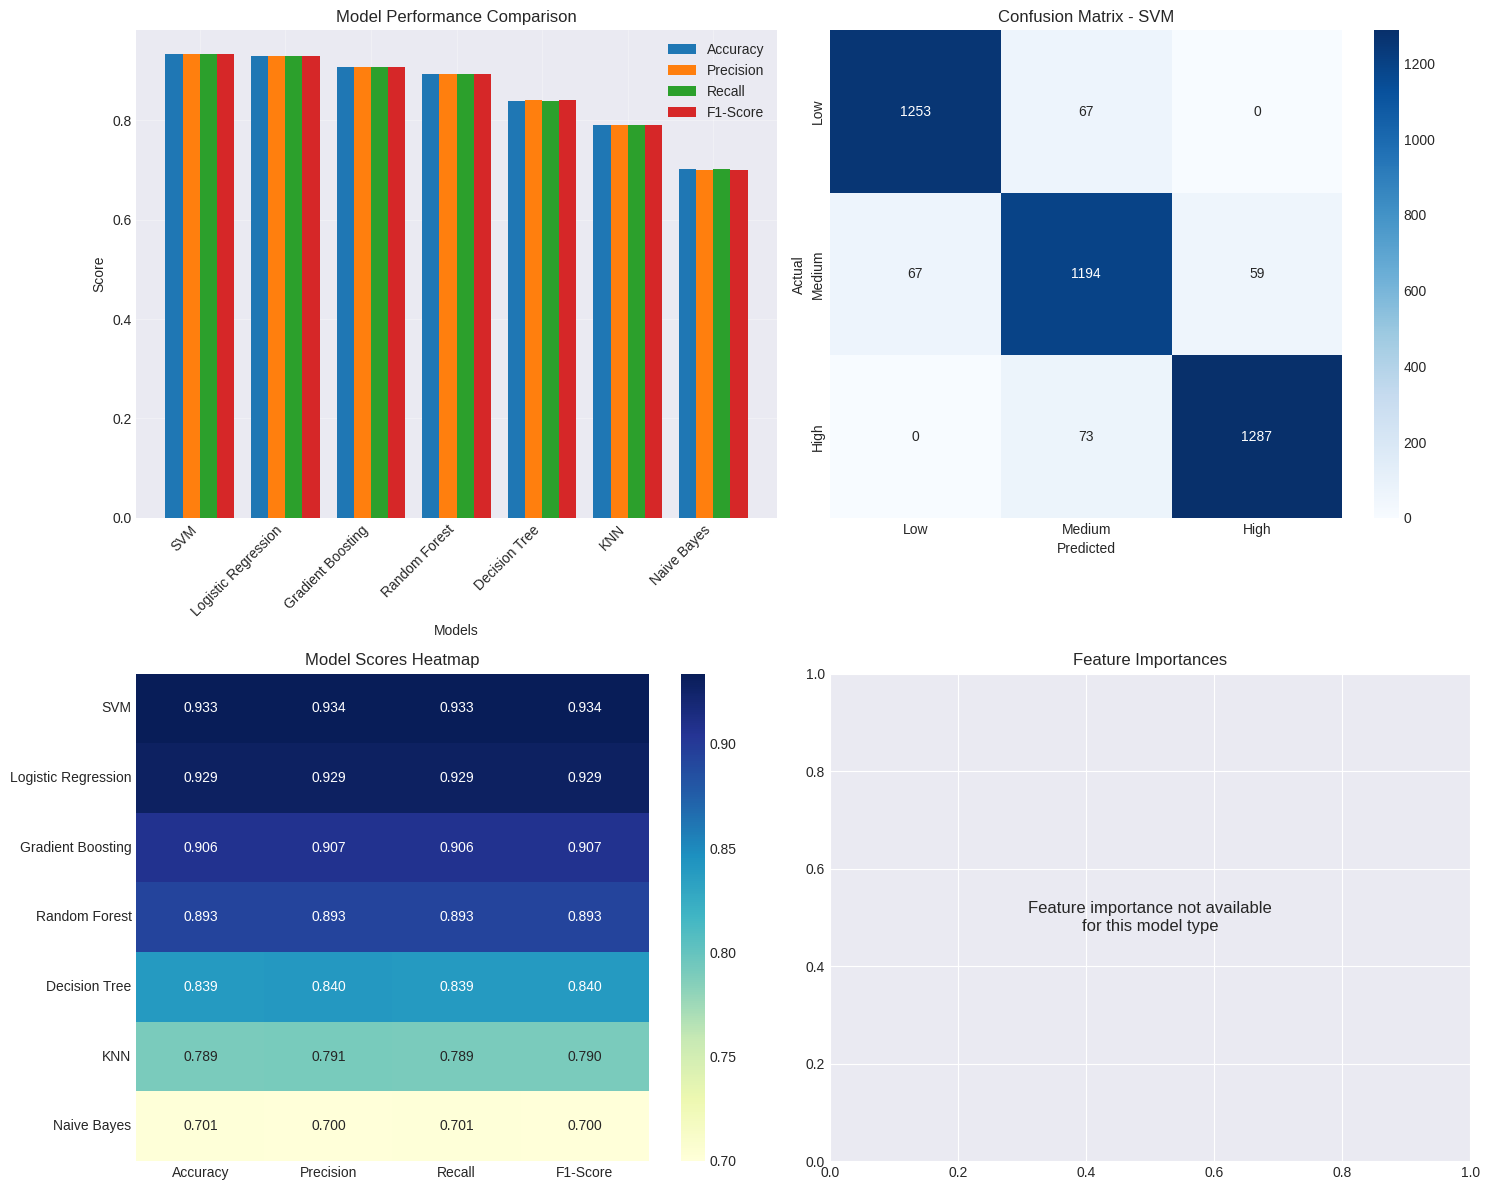

✅ Visualizations saved as 'classification_evaluation.png'


In [32]:
print("\n" + "=" * 60)
print("Creating Visualizations")
print("=" * 60)

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model Comparison Bar Chart
ax1 = axes[0, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df['Model']))
width = 0.2

for i, metric in enumerate(metrics):
    ax1.bar(x + i*width, comparison_df[metric], width, label=metric)

ax1.set_xlabel('Models')
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Confusion Matrix of Best Model
ax2 = axes[0, 1]
best_pred = evaluation_results[best_model]['Predictions']
cm_best = confusion_matrix(y_test, best_pred)

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
ax2.set_title(f'Confusion Matrix - {best_model}')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# 3. Model Scores Comparison (Heatmap)
ax3 = axes[1, 0]
scores_matrix = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].values
sns.heatmap(scores_matrix, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax3,
            xticklabels=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
            yticklabels=comparison_df['Model'])
ax3.set_title('Model Scores Heatmap')

# 4. Feature Importance (for best model if available)
ax4 = axes[1, 1]
best_model_obj = all_models[best_model]

if hasattr(best_model_obj, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': best_model_obj.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)
    
    ax4.barh(feature_importance['Feature'], feature_importance['Importance'])
    ax4.set_xlabel('Importance')
    ax4.set_title(f'Top 10 Feature Importances - {best_model}')
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Feature importance not available\nfor this model type', 
             ha='center', va='center', fontsize=12)
    ax4.set_title('Feature Importances')

plt.tight_layout()
plt.savefig('classification_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved as 'classification_evaluation.png'")

# 6. SAVE EVALUATION RESULTS

In [33]:
print("\n" + "=" * 60)
print("Saving Evaluation Results")
print("=" * 60)

# Save comparison dataframe
comparison_df.to_csv('classification_evaluation_results.csv', index=False)
print("✅ 'classification_evaluation_results.csv' saved")

# Save best model info
best_model_info = {
    'best_model': best_model,
    'best_accuracy': best_accuracy,
    'best_model_object': all_models[best_model]
}
print(f"✅ Best model: {best_model} (Accuracy: {best_accuracy:.4f})")

print("\n✅ Prediction and Evaluation completed successfully!")


Saving Evaluation Results
✅ 'classification_evaluation_results.csv' saved
✅ Best model: SVM (Accuracy: 0.9335)

✅ Prediction and Evaluation completed successfully!


# PART 3: CLUSTREING 

In [1]:

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. LOAD DATA

In [5]:
print("=" * 60)
print("Loading Data for Clustering")
print("=" * 60)

# For clustering, we use only features (no target)
X_scaled = pd.read_csv('X_scaled_features.csv')
print(f"X_scaled shape: {X_scaled.shape}")

# Optionally reduce dimensionality for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"X_pca shape: {X_pca.shape}")

Loading Data for Clustering
X_scaled shape: (20000, 45)
X_pca shape: (20000, 2)


# 1. FIND OPTIMAL NUMBER OF CLUSTERS (Elbow Method)


Finding Optimal Number of Clusters (Elbow Method)


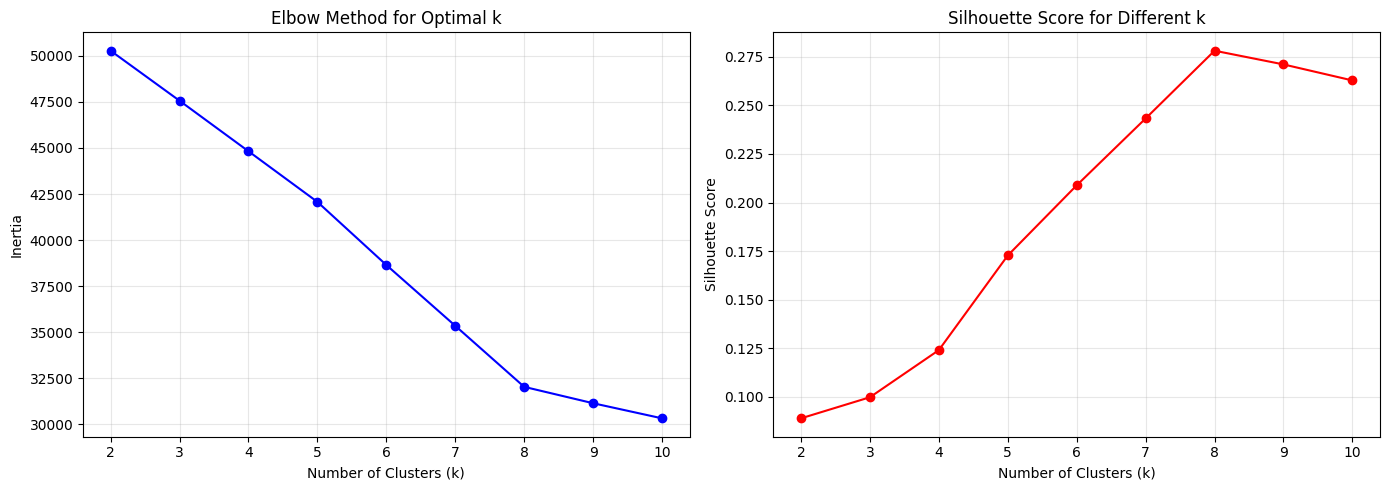

✅ Elbow and Silhouette plots saved as 'elbow_silhouette.png'


In [6]:
print("\n" + "=" * 60)
print("Finding Optimal Number of Clusters (Elbow Method)")
print("=" * 60)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Elbow plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Elbow and Silhouette plots saved as 'elbow_silhouette.png'")

# 2. K-MEANS CLUSTERING

In [8]:
print("\n" + "=" * 60)
print("K-Means Clustering")
print("=" * 60)

# Use optimal k (choose based on elbow or silhouette)
optimal_k = 8  # You can change this based on the plots
print(f"Using k = {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluation metrics
sil_score = silhouette_score(X_scaled, kmeans_labels)
db_score = davies_bouldin_score(X_scaled, kmeans_labels)
ch_score = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"\nK-Means Evaluation (k={optimal_k}):")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Score: {db_score:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

# Cluster distribution
unique, counts = np.unique(kmeans_labels, return_counts=True)
print(f"\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples ({count/len(kmeans_labels)*100:.1f}%)")



K-Means Clustering
Using k = 8

K-Means Evaluation (k=8):
Silhouette Score: 0.2782
Davies-Bouldin Score: 1.5362
Calinski-Harabasz Score: 2086.2788

Cluster Distribution:
  Cluster 0: 2488 samples (12.4%)
  Cluster 1: 2561 samples (12.8%)
  Cluster 2: 2449 samples (12.2%)
  Cluster 3: 2467 samples (12.3%)
  Cluster 4: 2582 samples (12.9%)
  Cluster 5: 2483 samples (12.4%)
  Cluster 6: 2457 samples (12.3%)
  Cluster 7: 2513 samples (12.6%)


# 3. HIERARCHICAL CLUSTERING

In [9]:
print("\n" + "=" * 60)
print("Hierarchical (Agglomerative) Clustering")
print("=" * 60)

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

# Evaluation metrics
sil_score_agg = silhouette_score(X_scaled, agglo_labels)
db_score_agg = davies_bouldin_score(X_scaled, agglo_labels)
ch_score_agg = calinski_harabasz_score(X_scaled, agglo_labels)

print(f"\nAgglomerative Clustering Evaluation (k={optimal_k}):")
print(f"Silhouette Score: {sil_score_agg:.4f}")
print(f"Davies-Bouldin Score: {db_score_agg:.4f}")
print(f"Calinski-Harabasz Score: {ch_score_agg:.4f}")

# Cluster distribution
unique, counts = np.unique(agglo_labels, return_counts=True)
print(f"\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples ({count/len(agglo_labels)*100:.1f}%)")



Hierarchical (Agglomerative) Clustering

Agglomerative Clustering Evaluation (k=8):
Silhouette Score: 0.2782
Davies-Bouldin Score: 1.5362
Calinski-Harabasz Score: 2086.2788

Cluster Distribution:
  Cluster 0: 2561 samples (12.8%)
  Cluster 1: 2449 samples (12.2%)
  Cluster 2: 2467 samples (12.3%)
  Cluster 3: 2582 samples (12.9%)
  Cluster 4: 2488 samples (12.4%)
  Cluster 5: 2483 samples (12.4%)
  Cluster 6: 2457 samples (12.3%)
  Cluster 7: 2513 samples (12.6%)


# 4. DBSCAN CLUSTERING

In [10]:
print("\n" + "=" * 60)
print("DBSCAN Clustering")
print("=" * 60)

# Try different epsilon values
eps_values = [0.5, 1.0, 1.5, 2.0]
best_dbscan = None
best_sil = -1

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    
    if n_clusters >= 2:
        try:
            sil = silhouette_score(X_scaled, dbscan_labels)
            print(f"eps={eps:.1f}: {n_clusters} clusters, {n_noise} noise, Silhouette: {sil:.4f}")
            if sil > best_sil:
                best_sil = sil
                best_dbscan = dbscan
        except:
            print(f"eps={eps:.1f}: {n_clusters} clusters, {n_noise} noise, Silhouette: N/A")

if best_dbscan is not None:
    dbscan_labels = best_dbscan.fit_predict(X_scaled)
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    
    print(f"\nBest DBSCAN: {n_clusters} clusters, {n_noise} noise points")
    print(f"Silhouette Score: {best_sil:.4f}")
else:
    print("DBSCAN did not find valid clusters with tested parameters")


DBSCAN Clustering
eps=0.5: 454 clusters, 6053 noise, Silhouette: -0.0928
eps=1.0: 24 clusters, 0 noise, Silhouette: 0.3291
eps=1.5: 8 clusters, 0 noise, Silhouette: 0.2782
eps=2.0: 8 clusters, 0 noise, Silhouette: 0.2782

Best DBSCAN: 24 clusters, 0 noise points
Silhouette Score: 0.3291


# 5. CLUSTERING COMPARISON

In [11]:
print("\n" + "=" * 60)
print("Clustering Algorithms Comparison")
print("=" * 60)

comparison_data = {
    'Algorithm': ['K-Means', 'Agglomerative', 'DBSCAN'],
    'Silhouette Score': [sil_score, sil_score_agg, best_sil if best_dbscan is not None else 'N/A'],
    'Davies-Bouldin': [db_score, db_score_agg, 'N/A'],
    'Calinski-Harabasz': [ch_score, ch_score_agg, 'N/A']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))



Clustering Algorithms Comparison
    Algorithm  Silhouette Score Davies-Bouldin Calinski-Harabasz
      K-Means          0.278164       1.536245       2086.278807
Agglomerative          0.278164       1.536245       2086.278807
       DBSCAN          0.329102            N/A               N/A


# 6. VISUALIZATIONS


Creating Clustering Visualizations


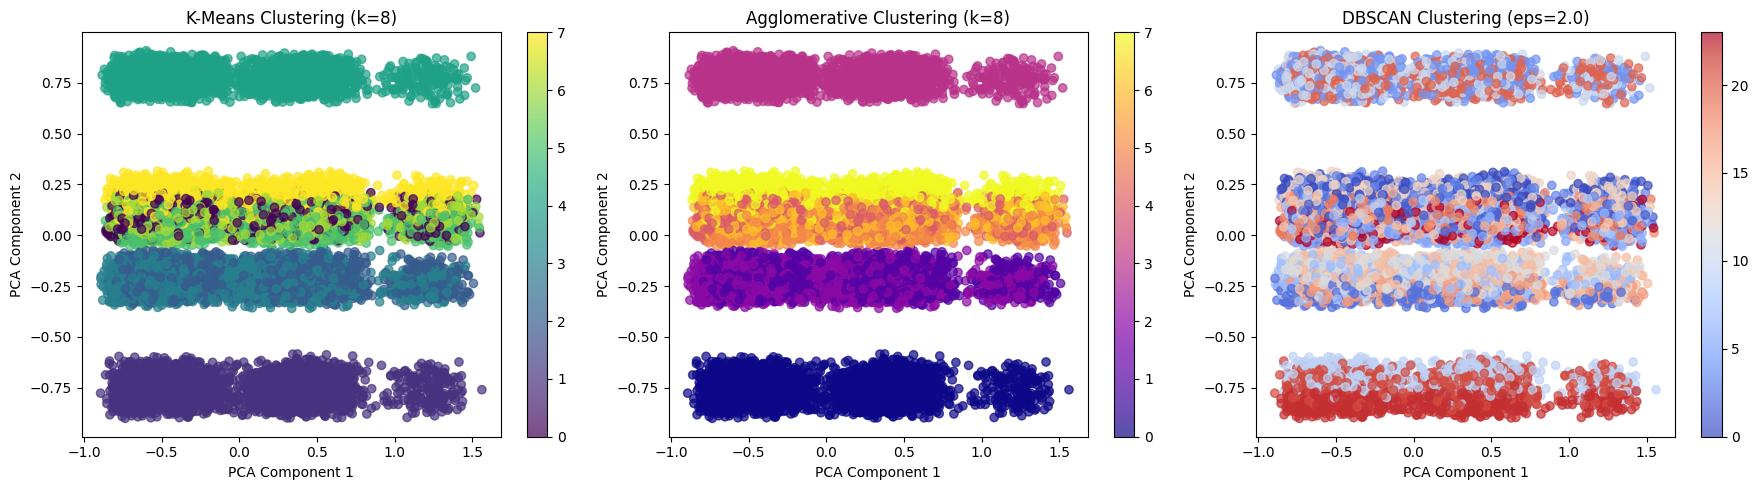

✅ Clustering visualizations saved as 'clustering_results.png'


In [12]:
print("\n" + "=" * 60)
print("Creating Clustering Visualizations")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. K-Means Clusters
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
axes[0].set_title(f'K-Means Clustering (k={optimal_k})')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(scatter1, ax=axes[0])

# 2. Agglomerative Clusters
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='plasma', alpha=0.7)
axes[1].set_title(f'Agglomerative Clustering (k={optimal_k})')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter2, ax=axes[1])

# 3. DBSCAN Clusters (if available)
if best_dbscan is not None:
    scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='coolwarm', alpha=0.7)
    axes[2].set_title(f'DBSCAN Clustering (eps={eps})')
    axes[2].set_xlabel('PCA Component 1')
    axes[2].set_ylabel('PCA Component 2')
    plt.colorbar(scatter3, ax=axes[2])
else:
    axes[2].text(0.5, 0.5, 'DBSCAN did not find valid clusters', 
                 ha='center', va='center', fontsize=12)
    axes[2].set_title('DBSCAN Clustering')

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Clustering visualizations saved as 'clustering_results.png'")


# 7. HIERARCHICAL DENDROGRAM


Creating Hierarchical Dendrogram


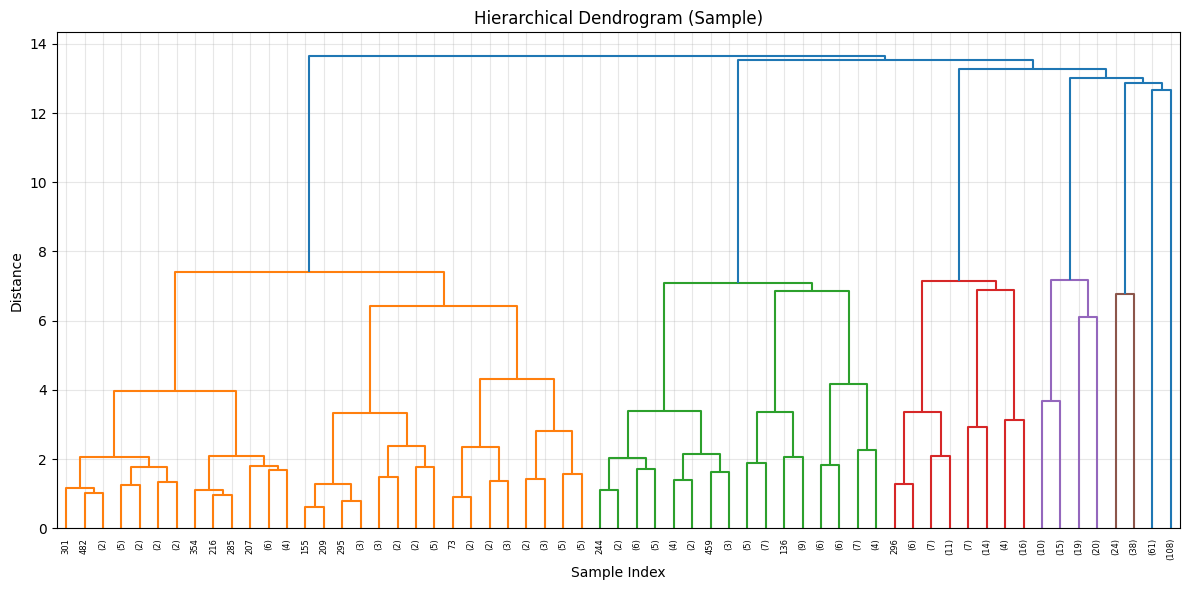

✅ Dendrogram saved as 'dendrogram.png'


In [13]:
print("\n" + "=" * 60)
print("Creating Hierarchical Dendrogram")
print("=" * 60)

# Sample data for dendrogram (use subset for better visualization)
sample_size = min(500, len(X_scaled))
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled.iloc[sample_indices]

# Calculate linkage
linked = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=5, show_leaf_counts=True)
plt.title('Hierarchical Dendrogram (Sample)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Dendrogram saved as 'dendrogram.png'")

# 8. SAVE CLUSTERING RESULTS


In [14]:
print("\n" + "=" * 60)
print("Saving Clustering Results")
print("=" * 60)

# Add cluster labels to original data
df_cluster = pd.read_csv('X_scaled_features.csv')
df_cluster['KMeans_Cluster'] = kmeans_labels
df_cluster['Agglo_Cluster'] = agglo_labels
if best_dbscan is not None:
    df_cluster['DBSCAN_Cluster'] = dbscan_labels

df_cluster.to_csv('clustering_results.csv', index=False)
print("✅ 'clustering_results.csv' saved")

# Save cluster models
import joblib
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(agglo, 'agglo_model.pkl')
if best_dbscan is not None:
    joblib.dump(best_dbscan, 'dbscan_model.pkl')

print("✅ Cluster models saved (.pkl files)")

# Save summary
clustering_summary = {
    'optimal_k': optimal_k,
    'kmeans_silhouette': sil_score,
    'agglo_silhouette': sil_score_agg,
    'dbscan_best_eps': eps if best_dbscan is not None else None,
    'dbscan_silhouette': best_sil if best_dbscan is not None else None
}
joblib.dump(clustering_summary, 'clustering_summary.pkl')
print("✅ 'clustering_summary.pkl' saved")

print("\n✅ Clustering completed successfully!")


Saving Clustering Results
✅ 'clustering_results.csv' saved
✅ Cluster models saved (.pkl files)
✅ 'clustering_summary.pkl' saved

✅ Clustering completed successfully!


# 9. CLUSTER ANALYSIS (Interpretation)


In [15]:
print("\n" + "=" * 60)
print("Cluster Analysis (K-Means)")
print("=" * 60)

# Analyze cluster characteristics
for cluster_id in range(optimal_k):
    cluster_data = X_scaled[kmeans_labels == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)}")
    print(f"  Mean values (top 5 features):")
    # Get top 5 most important features for this cluster
    means = cluster_data.mean()
    top_features = means.abs().sort_values(ascending=False).head(5)
    for feat, val in top_features.items():
        print(f"    {feat}: {val:.3f}")

print("\n✅ All analyses completed successfully!")


Cluster Analysis (K-Means)

Cluster 0:
  Size: 2488
  Mean values (top 5 features):
    Industry_Logistics: 1.000
    Routine_Task_Percentage: 0.497
    Age: 0.488
    Creativity_Requirement: 0.479
    Human_Interaction_Level: 0.472

Cluster 1:
  Size: 2561
  Mean values (top 5 features):
    Industry_Healthcare: 1.000
    Human_Interaction_Level: 0.569
    Routine_Task_Percentage: 0.492
    Age: 0.491
    Creativity_Requirement: 0.482

Cluster 2:
  Size: 2449
  Mean values (top 5 features):
    Industry_Education: 1.000
    Human_Interaction_Level: 0.572
    Routine_Task_Percentage: 0.507
    Age: 0.498
    Creativity_Requirement: 0.469

Cluster 3:
  Size: 2467
  Mean values (top 5 features):
    Industry_Retail: 1.000
    Human_Interaction_Level: 0.569
    Age: 0.503
    Creativity_Requirement: 0.492
    Routine_Task_Percentage: 0.483

Cluster 4:
  Size: 2582
  Mean values (top 5 features):
    Industry_Telecom: 1.000
    Company_Size: 0.499
    Routine_Task_Percentage: 0.491
    Ag